# When do Pit Stops Happen in F1?<br>
### A Small Data Classification Project by Ivry Frost<br>

## Introduction

In this notebook, you will see an analysis of multi layer perceptron machine learning models used to predict when an F1 driver will come in for a pit stop. These models could be used in an application that allows F1 teams to input race data as it happens while continuously outputting the likelihood of opponents pit stopping on the next lap. Another way to implement this would be as a binary classifier by choosing a threshold, with percentages above the threshold outputting a "Will pit soon" result. 

### Data
The data used is provided by Aadi Gupta, who made a kaggle dataset using the FastF1 API to get data from F1 races. This dataset is very large, so to trim it down I will only be training the models on the race data from 2025. This reduces the data to 27,040 points, which is more than enough. Another benefit of this is that the race data is newer, meaning the pitting strategies featured in the data are all the newest meta-game of the sport. 

### Stakeholders, Risks, and Mitigation of Risk

The primary stakeholder of an application that can predict pit stops are F1 race teams, that could use this application to set their strategies while racing. Thus, the ethical risk of an application like this is related to sporting integrity - is using this application cheating? That question must be considered before implementation. To remove the ethical concerns, bringing an application like this to the F1 rules committee and letting them decide on when/how to allow implementation would be the best way to ensure integrity. 

### Additional Testing
I will be testing my model by using train-test-split on the 2025 race data. However, there are two additional ways that it can be tested. The first is to test it on the data in this dataset from other years (2022 through 2024). The second, which is more fun, would be to create the application  mentioned in the introduction (a simple version could be fairly easily implemented as a terminal game), and try it out from home as a race is occurring. The downside of the at home implementation is that the metrics are a fair bit less vast (the testing would be for essentially one data point if one driver was being followed during one race). 

### Needed Accuracy to Create Value
This application will not be used to save someone's life. However, F1 teams value precision and likely would not use a tool that is not reliable. Thus, I believe an accuracy of 80% would be acceptable if the application displayed percentages instead of a binary result, because teams would have more knowledge if they knew how certain the model was, which reduces a need for accuracy.



## Model Building, Visualizing, and Testing

### Noteboook Setup
To start, we will import the necessary libraries for this project.

In [269]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt

### Data Preprocessing
The next step is to get our data in the form we want it. The first two excluded columns from the training data will be the year (it is constant), as well as the output column, PitNextLap,which will be popped into Y_data. Additionally, the driver and race location will be omitted because doing OneHotEncoding on two features, both with many options, results in too many input features, which could reduce accuracy. In the future, models could be trained on specific race locations or for specific drivers, which would allow for targeted use of the application for a race or opponent. The tire compound was encoded using OneHotEncoding, as there are only a few options and it is an important variable to consider when thinking about pitting. 

In [270]:
# Loading the data
data = pd.read_csv("f1_strategy_dataset_v4.csv")  # loading the data
data = data.loc[data["Year"].astype(str) == "2025"]  # Filtering for just 2025 races

# Dropping unused columns and splitting into X and Y data
columns_to_drop = ["Driver", "Race", "Year"]
X_dataframe = data.drop(columns_to_drop, axis=1)  # Dropping unneeded columns
Y_dataframe = data.pop("PitNextLap")  # Moving the y data into its own dataframe

# Encoding tire compound column using OneHotEncoding from SciKit-Learn
encoder = OneHotEncoder()  # makes an encoder
columns_to_encode = ["Compound"]  # columns to be changed - just the tire compound
encoded_columns = encoder.fit_transform(
    X_dataframe[columns_to_encode]
).toarray()  # converts the column to a dataframe with the encoded values
encoded_df = pd.DataFrame(
    encoded_columns, columns=encoder.get_feature_names_out()
)  # convert to dataframe
X_dataframe = X_dataframe.drop(columns=columns_to_encode)  # Drop the old tire column
X_dataframe = X_dataframe.reset_index(
    drop=True
)  # reset the index to prep concatenation
X_dataframe = pd.concat(
    [X_dataframe, encoded_df], axis=1
)  # concatenate dataframes to finish encoding process

# Converting our data to tensors for use in pytorch
X_data = torch.tensor(X_dataframe.values, dtype=torch.float32)
Y_data = torch.tensor(Y_dataframe.values, dtype=torch.float32)

# Using train-test-split to finish prepping our data
X_train, X_test, y_train, y_test = train_test_split(
    X_data, Y_data, test_size=0.3, random_state=42
)
# Et voila! Our data is good to go

### Making and Implementing the First Iteration of the Model
The following code is a very standard implementation of the torch.nn module, which will create a multi layer perceptron (MLP) neural network. To start, a simple architecture will be used, with one input, output, and hidden layer. The hidden layer will be the size of the geometric mean of 16 and 1 (the input and output layers), which is 4. 

In [271]:
# Defining the model
class MLP_1(nn.Module):
    def __init__(self, input, hidden, output):
        super(MLP_1, self).__init__()
        self.linear_1 = nn.Linear(input, hidden)
        self.linear_2 = nn.Linear(hidden, output)

    def forward(self, x):
        out = self.linear_1(x)
        out = F.sigmoid(out)
        out = self.linear_2(out)
        # We are omitting softmax here, because our loss function later will handle it.
        return out

Next, we will make our model instance, define our epochs and learning rate parameters, set up our loss function and optimizer, and make numpy arrays to store our results. 

In [272]:
# Creating a model and setting up parameters
model = MLP_1(16, 4, 1)
n_epochs = 1000
learning_rate = 0.001
criterion = (
    nn.BCEWithLogitsLoss()
)  # Using Binary log loss because it is binary classifier
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
train_losses_mlp = np.zeros((n_epochs,))
test_losses_mlp = np.zeros((n_epochs,))
accuracies_mlp = np.zeros((n_epochs,))

The last step in implementing the model is to run our data through it. This will be done in a for loop, which runs our x_train through the model and compares the results with y train, before calculating the gradients of the losses and moving in a step along them. Additionally, we will be implementing an evaluation stage into each loop, so that we can see how the model gets more accurate over time. 

In [273]:
# Implementing a training loop
for epoch in range(n_epochs):
    optimizer.zero_grad()
    model.train()
    outputs = model(
        X_train
    ).squeeze()  # Squeezing to make the dimensions match for the loss function
    loss = criterion(outputs, y_train)
    train_losses_mlp[epoch] = loss.item()

    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test).squeeze()
        test_loss = criterion(test_outputs, y_test)
        test_losses_mlp[epoch] = test_loss.item()
        accuracies_mlp[epoch] = (
            torch.sum((torch.sigmoid(test_outputs) >= 0.5) == y_test)
            / y_test.shape[0]  # Using a threshold of 0.5 in this case
        ).item()
    loss.backward()
    optimizer.step()

We have now implemented our first model!

### Testing and Visualization 1

Now that we have trained our model, there are a few things to look at. The first two metrics are accuracy and loss functions over the course of our epochs. Below is the visualization of this:

Text(0.5, 1.0, 'Accuracy')

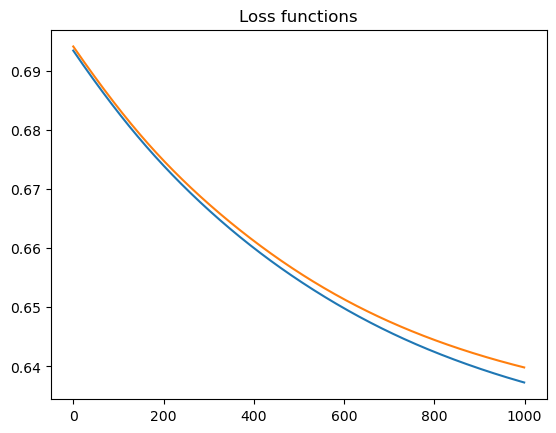

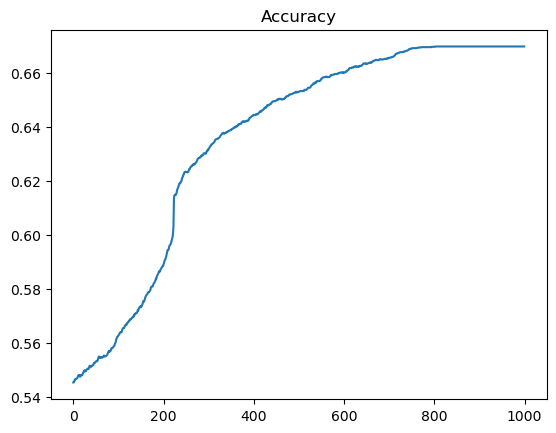

In [274]:
plt.figure()
plt.plot(range(n_epochs), train_losses_mlp, label="train cross-entropy (mlp)")
plt.plot(range(n_epochs), test_losses_mlp, label="test cross-entropy (mlp)")
plt.title("Loss functions")
plt.figure()
plt.plot(range(n_epochs), accuracies_mlp)
plt.title("Accuracy")

### WELP - that's not good!
A problem that is very common happened to us - our dataset is unbalanced, with the amount of drivers not pitting being around twice as prevalent as drivers pitting. This has led to our model guessing that the driver never pits! This is shown in the bar graph below. 

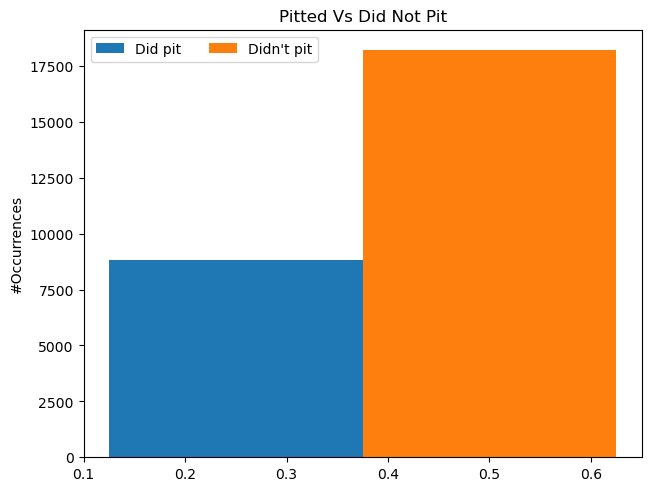

In [275]:
pos_bar = sum(Y_dataframe)
neg_bar = len(Y_dataframe) - pos_bar
width = 0.25
fig, ax = plt.subplots(layout="constrained")
ax.bar(0.25, pos_bar, 0.25, label="Did pit")
ax.bar(0.5, neg_bar, 0.25, label="Didn't pit")
ax.set_ylabel("#Occurrences")
ax.set_title("Pitted Vs Did Not Pit")

ax.legend(loc="upper left", ncols=2)

To verify this, we can check to see that the ratio of not pitting to the total number of data points matches the accuracy - this would imply that the model is guessing the more common result every time.

In [ ]:
# Getting the pitted, didn't pit, and total values so that we can take our ratio
pitted = sum(Y_dataframe)
total = len(Y_dataframe)
didnt_pit = total - pitted
ratio_1 = didnt_pit / total


print(
    f"{ratio_1} (ratio) and {accuracies_mlp[-1]} (final accuracy value) are pretty close to each other!"
)

0.673335798816568 (ratio) and 0.6697485446929932 (final accuracy value) are pretty close to each other!


### What's next?
Sometimes, getting a result like the one we just got leads to a very common fix - balancing the dataset. However, I am confident that this dataset has correlations between the input features and the result, and if I am right then we don't *need* to balance the dataset, because if there is real correlation then the model shouldn't guess the most common result. 

In the next iteration of the model, we are going to try two things: I am going to switch from an SGD optimizer to ADAM (if the 0.67 ratio is a local minimum, this should help the model escape it), and I am going to increase the number of nodes in the hidden layer to 32 to help find more complex patterns. 

The following blocks of code are nearly identical to the ones above, just with the optimizer.SGD line and number of hidden nodes being changed.

Text(0.5, 1.0, 'Accuracy')

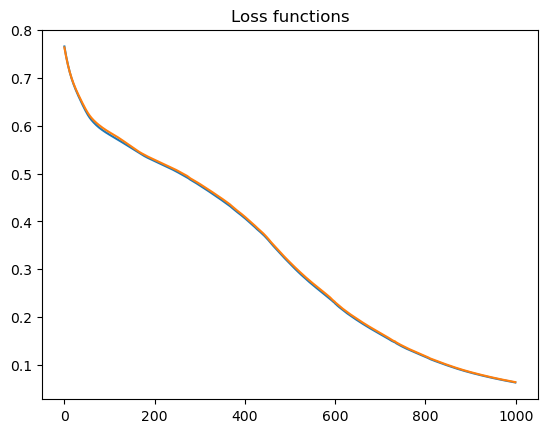

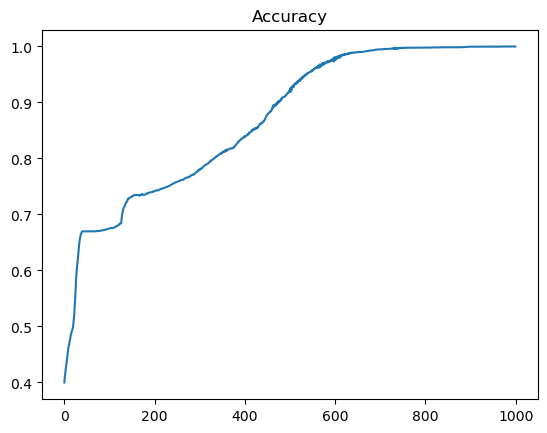

In [277]:
# The model class definition is the same

# setting up the model
model = MLP_1(16, 32, 1)
n_epochs = 1000
learning_rate = 0.001
criterion = (
    nn.BCEWithLogitsLoss()
)  # Using Binary log loss because it is binary classifier
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_losses_mlp = np.zeros((n_epochs,))
test_losses_mlp = np.zeros((n_epochs,))
accuracies_mlp = np.zeros((n_epochs,))

# running the for loop
for epoch in range(n_epochs):
    optimizer.zero_grad()
    model.train()
    outputs = model(
        X_train
    ).squeeze()  # Squeezing to make the dimensions match for the loss function
    loss = criterion(outputs, y_train)
    train_losses_mlp[epoch] = loss.item()

    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test).squeeze()
        test_loss = criterion(test_outputs, y_test)
        test_losses_mlp[epoch] = test_loss.item()
        accuracies_mlp[epoch] = (
            torch.sum((torch.sigmoid(test_outputs) >= 0.5) == y_test)
            / y_test.shape[0]  # Using a threshold of 0.5 in this case
        ).item()
    loss.backward()
    optimizer.step()

# plotting
plt.figure()
plt.plot(range(n_epochs), train_losses_mlp, label="train cross-entropy (mlp)")
plt.plot(range(n_epochs), test_losses_mlp, label="test cross-entropy (mlp)")
plt.title("Loss functions")
plt.figure()
plt.plot(range(n_epochs), accuracies_mlp)
plt.title("Accuracy")

### Well that worked!

Switching to Adam and adding layers completely fixed it! 

I will note that although it isn't in the submission, I attempted those interventions separately and though adding layers helps, switching to ADAM is what made it get such a high accuracy. I am assuming that ADAM made the model work because it pushed it out of the local minimum that is the 0.67 ratio, allowing it to progress past the point that an SGD optimizer would stop. 



### One last intervention...

though the model is I daresay near perfect, I want to play around with adding a hidden layer to see if that can increase the speed at which the model improves. 
the following code is going to be much the same to the second iteration of this implementation, but with the class definition being new (one extra layer and a relu function between the first two layers).

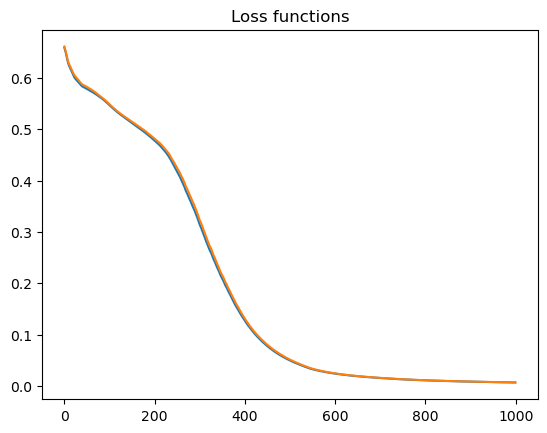

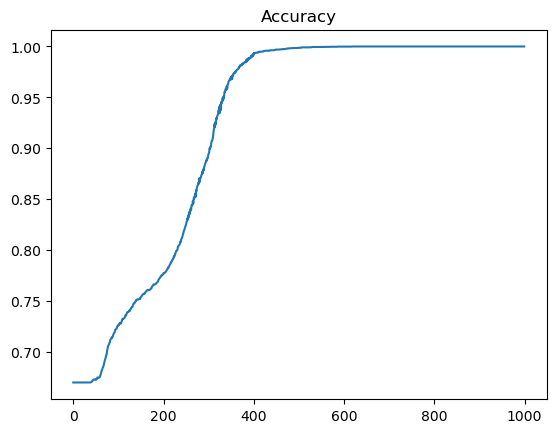

In [278]:
# Defining the model
class MLP_2(nn.Module):
    def __init__(self, input, hidden_1, hidden_2, output):
        super(MLP_2, self).__init__()
        self.linear_1 = nn.Linear(input, hidden_1)
        self.linear_2 = nn.Linear(hidden_1, hidden_2)
        self.linear_3 = nn.Linear(hidden_2, output)

    def forward(self, x):
        out = self.linear_1(x)
        out = F.relu(out)
        out = self.linear_2(out)
        out = F.sigmoid(out)
        out = self.linear_3(out)
        # We are omitting softmax here, because our loss function later will handle it.
        return out


# setting up the model
model = MLP_2(16, 32, 16, 1)
n_epochs = 1000
learning_rate = 0.001
criterion = (
    nn.BCEWithLogitsLoss()
)  # Using Binary log loss because it is binary classifier
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_losses_mlp = np.zeros((n_epochs,))
test_losses_mlp = np.zeros((n_epochs,))
accuracies_mlp = np.zeros((n_epochs,))

# running the for loop
for epoch in range(n_epochs):
    optimizer.zero_grad()
    model.train()
    outputs = model(
        X_train
    ).squeeze()  # Squeezing to make the dimensions match for the loss function
    loss = criterion(outputs, y_train)
    train_losses_mlp[epoch] = loss.item()

    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test).squeeze()
        test_loss = criterion(test_outputs, y_test)
        test_losses_mlp[epoch] = test_loss.item()
        accuracies_mlp[epoch] = (
            torch.sum((torch.sigmoid(test_outputs) >= 0.5) == y_test)
            / y_test.shape[0]  # Using a threshold of 0.5 in this case
        ).item()
    loss.backward()
    optimizer.step()

# plotting
plt.figure()
plt.plot(range(n_epochs), train_losses_mlp, label="train cross-entropy (mlp)")
plt.plot(range(n_epochs), test_losses_mlp, label="test cross-entropy (mlp)")
plt.title("Loss functions")
plt.figure()
plt.plot(range(n_epochs), accuracies_mlp)
plt.title("Accuracy")
plt.show()

### It is quicker!

As predicted, this model reaches a similar accuracy to the last one, but this one reaches it in roughly 400 epochs instead of the roughly 600 that was the case for the last model. 

### Final Evaluation

Looking at the code block below, you can see that the accuracy reached 100% in the third model. Though this typically means something went wrong, in this case I believe it is due to the X data being very correlated with the Y data. The input features all have a lot of input as to whether or not a driver will pit, so an ML model being able to perfectly predict this result is not shocking to me. 

In [279]:
print(accuracies_mlp[-1])

1.0
